<a href="https://colab.research.google.com/github/Garimaahuja04/Instagram-performance-analyser/blob/main/instagramanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analyzing Instagram post performance
5,000 posts across all formats
Processing engagement metrics...
Analyzed 5,000 posts
Average engagement by type:
  Post  :   1839 points
  Reel  :   3694 points
  Story :    928 points

Peak performance: 19:00 (3432 points)
Reel performance significance: p=0.00e+00
Creating performance visualizations...


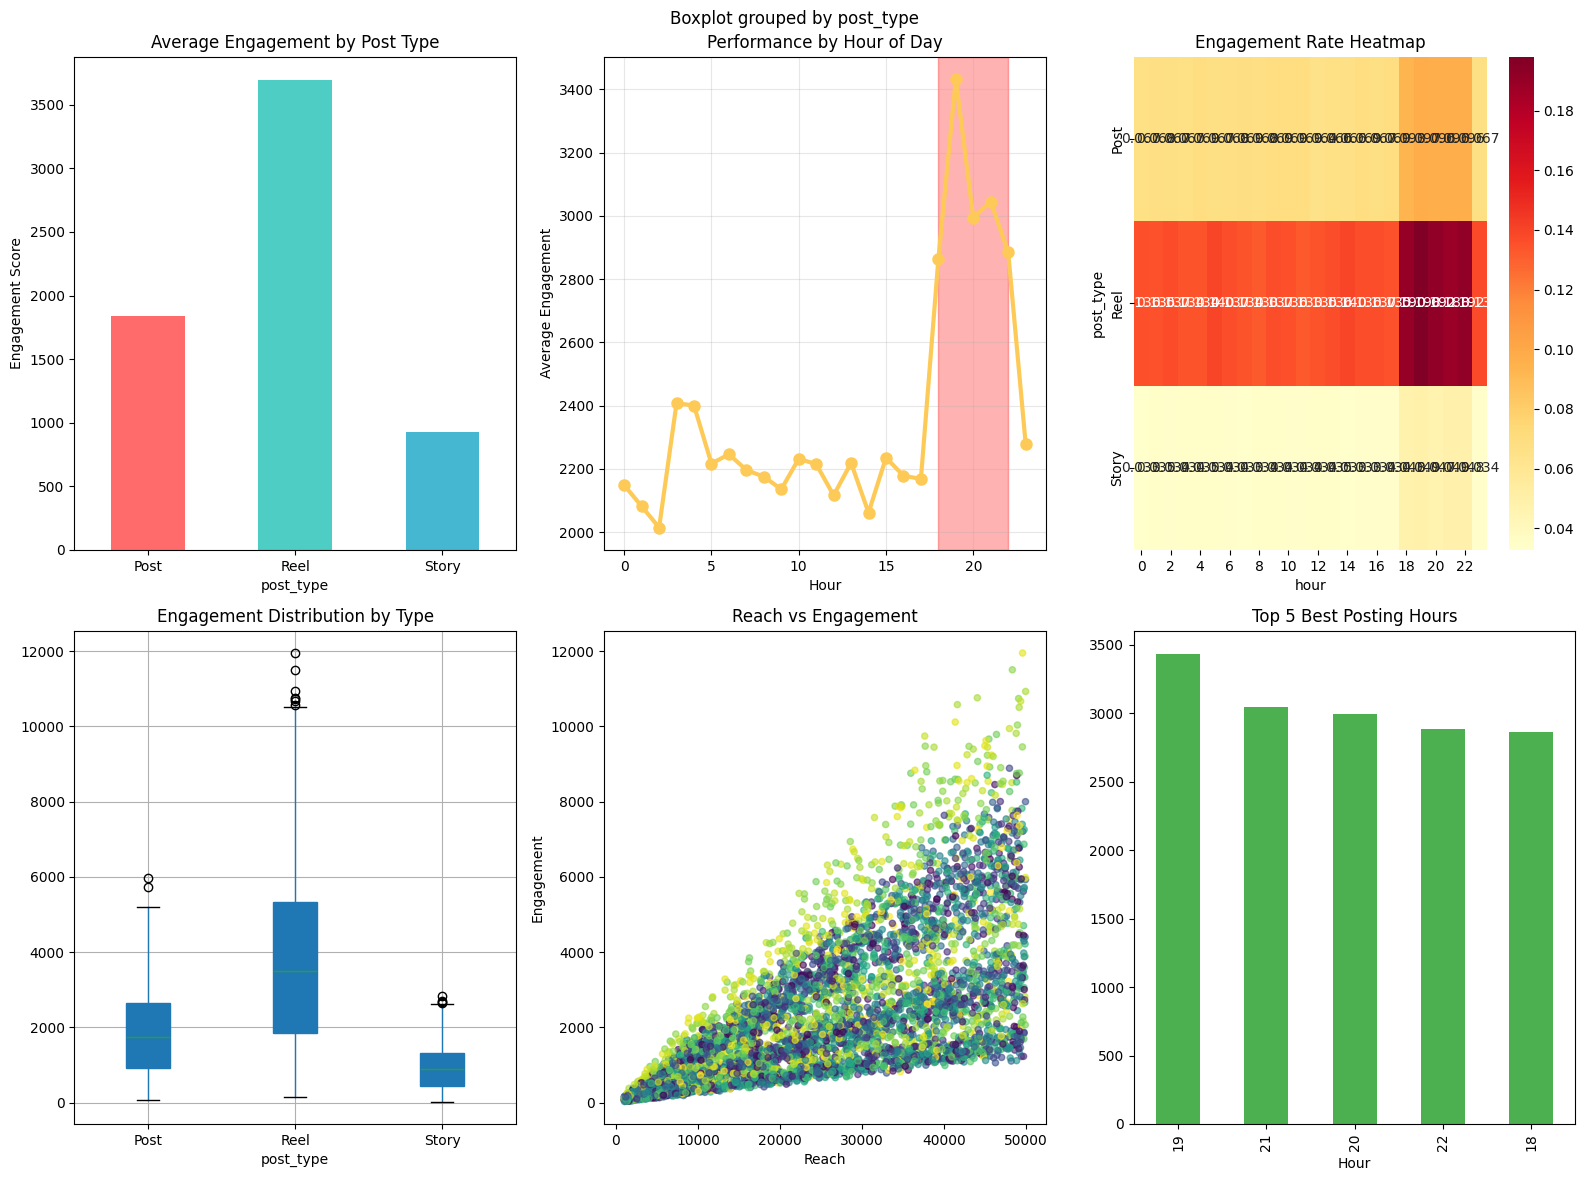


Analysis complete.
Visualization saved as instagram_performance.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def process_engagement_data():
    """Generate and process Instagram engagement data"""
    print("Analyzing Instagram post performance")
    print("5,000 posts across all formats")

    np.random.seed(42)
    n_posts = 5000

    data = {
        'post_type': np.random.choice(['Reel', 'Post', 'Story'], n_posts, p=[0.4, 0.35, 0.25]),
        'hour': np.random.choice(range(24), n_posts),
        'reach': np.random.randint(1000, 50000, n_posts)
    }

    df = pd.DataFrame(data)
    base_date = pd.Timestamp('2023-01-01')
    df['post_datetime'] = [base_date + pd.Timedelta(hours=h) for h in df['hour']]

    print("Processing engagement metrics...")

    # Calculate realistic engagement
    for idx, row in df.iterrows():
        hour, post_type, reach = row['hour'], row['post_type'], row['reach']

        base_rates = {'Reel': 0.08, 'Post': 0.04, 'Story': 0.02}
        evening_boost = 1 + 0.4 * (1 if 18 <= hour <= 22 else 0)

        likes = int(reach * base_rates[post_type] * evening_boost * np.random.uniform(0.8, 1.2))
        comments = int(likes * np.random.uniform(0.1, 0.3))
        shares = int(likes * np.random.uniform(0.05, 0.15))

        df.at[idx, 'likes'] = max(0, likes)
        df.at[idx, 'comments'] = max(0, comments)
        df.at[idx, 'shares'] = max(0, shares)

    df['total_engagement'] = df['likes'] + df['comments']*2 + df['shares']*3
    df['engagement_rate'] = df['total_engagement'] / df['reach']

    return df

def analyze_performance(df):
    """Calculate key performance metrics"""
    print(f"Analyzed {len(df):,} posts")

    type_summary = df.groupby('post_type')['total_engagement'].mean().round(0)
    print(f"Average engagement by type:")
    for post_type, score in type_summary.items():
        print(f"  {post_type:6}: {score:6.0f} points")

    hourly_peak = df.groupby('hour')['total_engagement'].mean().idxmax()
    peak_score = df.groupby('hour')['total_engagement'].mean().max()
    print(f"\nPeak performance: {hourly_peak}:00 ({peak_score:.0f} points)")

    # Statistical test
    reels = df[df['post_type']=='Reel']['total_engagement']
    posts = df[df['post_type']=='Post']['total_engagement']
    stories = df[df['post_type']=='Story']['total_engagement']

    f_stat, p_value = stats.f_oneway(reels, posts, stories)
    print(f"Reel performance significance: p={p_value:.2e}")

    return type_summary

def create_visualizations(df, type_summary):
    """Generate comprehensive performance charts"""
    print("Creating performance visualizations...")

    fig, axes = plt.subplots(2, 3, figsize=(16, 12))
    fig.suptitle('Instagram Content Performance Analysis', fontsize=20, fontweight='bold')

    # Post type comparison
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    type_summary.plot(kind='bar', ax=axes[0,0], color=colors)
    axes[0,0].set_title('Average Engagement by Post Type')
    axes[0,0].set_ylabel('Engagement Score')
    axes[0,0].tick_params(axis='x', rotation=0)

    # Hourly performance trends
    hourly = df.groupby('hour')['total_engagement'].mean()
    axes[0,1].plot(hourly.index, hourly.values, 'o-', linewidth=3,
                   color='#FECA57', markersize=8)
    axes[0,1].axvspan(18, 22, alpha=0.3, color='red')
    axes[0,1].set_title('Performance by Hour of Day')
    axes[0,1].set_xlabel('Hour')
    axes[0,1].set_ylabel('Average Engagement')
    axes[0,1].grid(True, alpha=0.3)

    # Engagement rate heatmap
    pivot = df.pivot_table('engagement_rate', 'post_type', 'hour', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,2])
    axes[0,2].set_title('Engagement Rate Heatmap')

    # Engagement distribution
    df.boxplot(column='total_engagement', by='post_type', ax=axes[1,0], patch_artist=True)
    axes[1,0].set_title('Engagement Distribution by Type')

    # Reach vs engagement correlation
    scatter = axes[1,1].scatter(df['reach'], df['total_engagement'],
                               alpha=0.6, c=df['hour'], cmap='viridis', s=20)
    axes[1,1].set_xlabel('Reach')
    axes[1,1].set_ylabel('Engagement')
    axes[1,1].set_title('Reach vs Engagement')

    # Top performing hours
    top_hours = df.groupby('hour')['total_engagement'].mean().nlargest(5)
    top_hours.plot(kind='bar', ax=axes[1,2], color='#4CAF50')
    axes[1,2].set_title('Top 5 Best Posting Hours')
    axes[1,2].set_xlabel('Hour')

    plt.tight_layout()
    plt.savefig('instagram_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

def main():
    """Main analysis pipeline"""
    # Process data
    df = process_engagement_data()

    # Analyze performance
    type_summary = analyze_performance(df)

    # Create visualizations
    create_visualizations(df, type_summary)

    print("\nAnalysis complete.")
    print("Visualization saved as instagram_performance.png")

if __name__ == "__main__":
    main()